# 08 · Active Learning — Which Biases to Measure

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/08_active_learning.ipynb)

Measurements cost time. Which bias points are most informative for recovering doping? High-bias points carry more diode signal, so a few well-chosen biases recover doping nearly as well as a full sweep.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.11.0+cu128


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate)
symlog = SymlogTransform(I0=1e-6)
biases = np.linspace(0.0, 0.6, 13)
profiles = [step(L) for L in np.geomspace(5e20, 5e22, 11)]
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog); norm = Normalizer.fit(X)
members=[]
for m in range(5):
    net = IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR, hidden=128, n_layers=3, seed=m))
    train_surrogate(net, X, Y, norm, epochs=2000, lr=2e-3); members.append(net)
half=N_ANCHOR//2
def encode_level(logL):
    C = torch.cat([-(10.0**logL).repeat(half),(10.0**logL).repeat(N_ANCHOR-half)])
    return scaling.doping_to_net_input(C)


## Recover doping from bias subsets

C:\Users\abhis\AppData\Local\Temp\ipykernel_2128\2966874368.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  recs.append(float(logL))


low 3   : median recovery error 0.029 decades
high 3  : median recovery error 0.012 decades
all 13  : median recovery error 0.008 decades


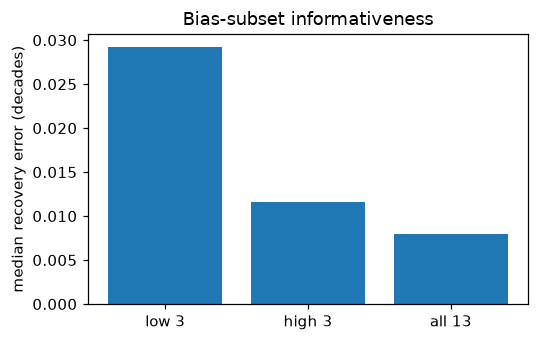

In [3]:

def recover(true_L, idx):
    Isg = sg_iv(step(true_L), biases)
    bs = torch.tensor(biases[idx]/VT, dtype=torch.float32)
    tgt = torch.tensor(symlog.forward(Isg[idx]), dtype=torch.float32)
    recs=[]
    for net in members:
        logL=torch.tensor(21.5, requires_grad=True); opt=torch.optim.Adam([logL],lr=0.05)
        for _ in range(400):
            opt.zero_grad(); lat=encode_level(logL)
            feats=torch.stack([torch.cat([lat,bs[i].reshape(1)]) for i in range(len(idx))])
            loss=torch.nn.functional.mse_loss(net((feats-norm.mean)/norm.std).reshape(-1), tgt)
            loss.backward(); opt.step(); logL.data.clamp_(20,23)
        recs.append(float(logL))
    return np.array(recs)

levels = np.geomspace(8e20, 3e22, 5)
strategies = {"low 3":[0,1,2], "high 3":[10,11,12], "all 13":list(range(13))}
res = {k:[abs(recover(L,idx).mean()-np.log10(L)) for L in levels] for k,idx in strategies.items()}
for k,v in res.items(): print(f"{k:8s}: median recovery error {np.median(v):.3f} decades")
plt.figure(figsize=(5,3.2))
plt.bar(range(len(res)), [np.median(v) for v in res.values()], tick_label=list(res.keys()))
plt.ylabel("median recovery error (decades)"); plt.title("Bias-subset informativeness")
plt.tight_layout(); plt.show()
